Importação da base de dados
Analise exploratoria dos dados: Inicialmente a base de dados possuia uma virgula após a ultima coluna, para nosso codigo isso era interpretado como uma coluna sem nome, essa virgula foi removida para evitar problemas de columas sem nome com dados nulos.
O campo diagnosis é a variavel target que informa se possui a doença como M ou não B, a variável é do tipo string e será tratada mais adiante no processo.



In [1]:
import pandas as pd
dados = pd.read_csv("dados/dados.csv",sep=',')
#Mostrar primeiras linhas e na sequencia resumo de quantidade de linhas e colunas
print(dados.head())
print(dados.shape)

#exibe os valores de um campo
print(set(dados.radius_mean))

#resumo dos dados
print(dados.describe())

#lista tipo de dados da base
"""  campo diagnosis é do tipo string, precisará ser tratado, este campo sera nossa variavel 
target pois informa se a pessoa esta ou não doente

"""

print(dados.info())






         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

Após analise visual importamos a bliblioteca missingno para fazer um double check e comprovar que não temos dados nulos na nossa base de dados

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


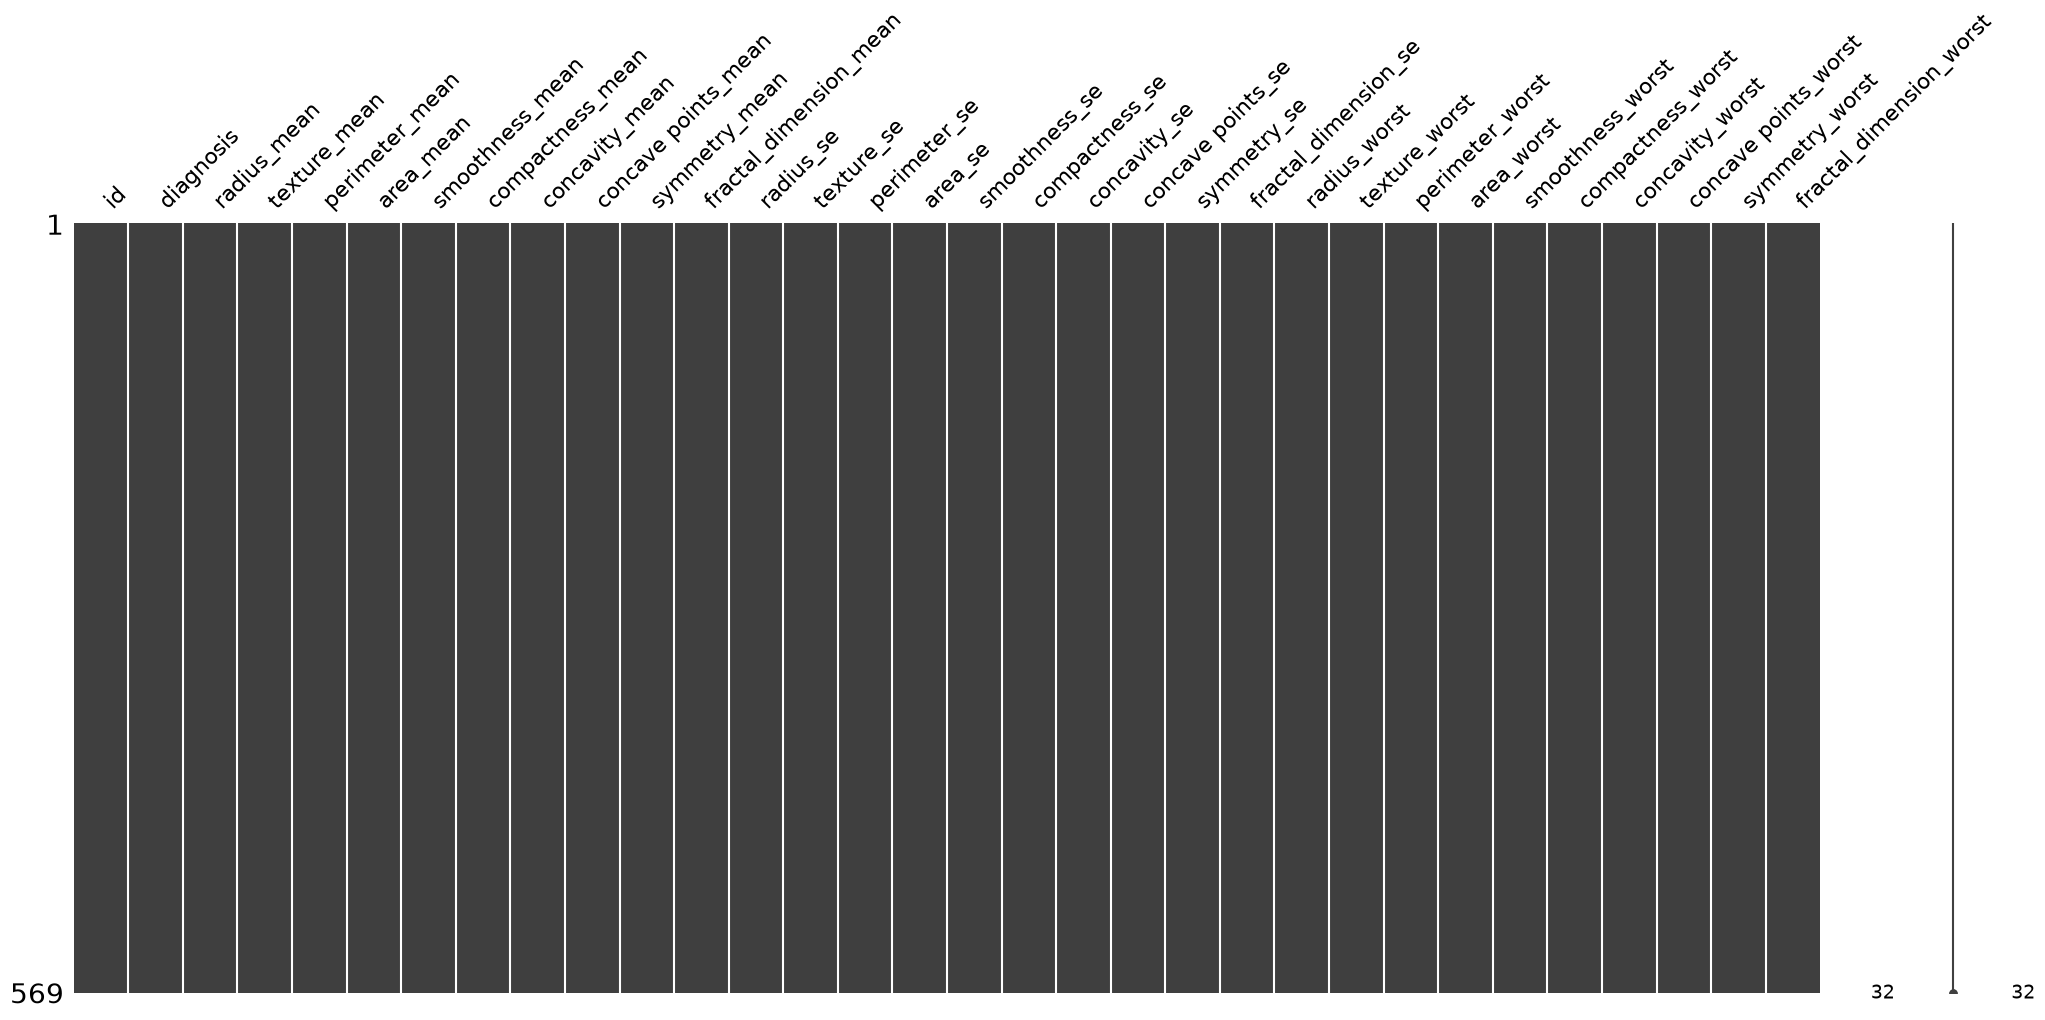

In [2]:
#importar bliblioteca para tratar dados nulos
import missingno as msno

#Exibe de forma grafica os dados nulos, novamente comprovando que o campo Unnamed esta somente com valores nulos
msno.matrix(dados)
# inicialmene a base de dados possuia o campo Unnamed com 569 registros nulos, 
#após essa verificação foi constatado a virgula adiconal após a ultima coluna
#essa virgula foi removida da base de dados e após nova execução nenhuma coluna possui dados nulos
print(dados.isnull().sum())



Comparação de variavies concave points_mean com diagnosis:
essa variavel possui uma correlação de 80% com nossa variavel target diagnosis, porém existem varios outlayers

<Axes: xlabel='diagnosis', ylabel='concave points_mean'>

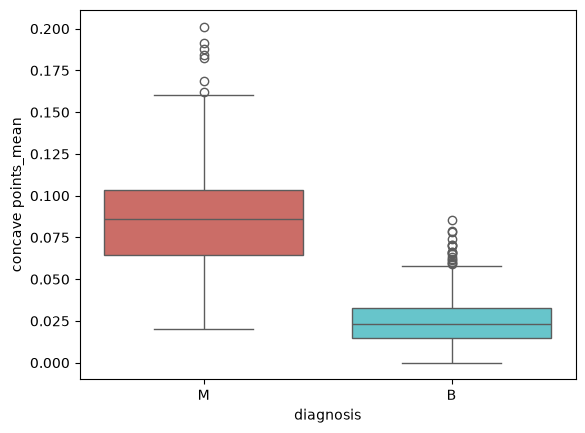

In [5]:
import seaborn as sb
sb.boxplot(
    x="diagnosis",
    y="concave points_mean",
    hue="diagnosis",
    data=dados,
    palette="hls",
    legend=False
)

Comparação de variavies concave points_worst com diagnosis:
essa variavel possui uma correlação de 80% com nossa variavel target diagnosis, e somente 2 outlayers para cada valor de diagnosis
entendemos que vai ser uma variavel muito importante durante as analises.

<Axes: xlabel='diagnosis', ylabel='concave points_worst'>

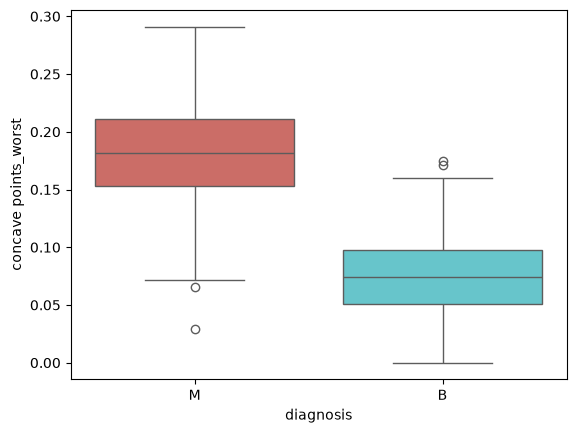

In [6]:
sb.boxplot(
    x="diagnosis",
    y="concave points_worst",
    hue="diagnosis",
    data=dados,
    palette="hls",
    legend=False
)

Comparação de variavies perimeter_worst com diagnosis:
essa variavel possui uma correlação de 80% com nossa variavel target diagnosis, e somente 3 outlayers quando diagnosis=M e 2 quando diagnosis = B
essa variavel tambem ser muito importante durante as analises.

<Axes: xlabel='diagnosis', ylabel='perimeter_worst'>

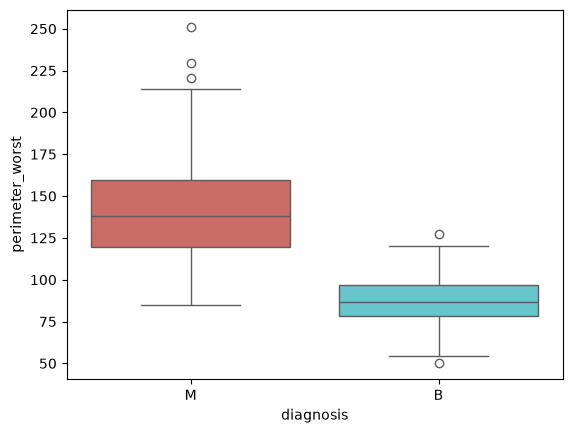

In [7]:
sb.boxplot(
    x="diagnosis",
    y="perimeter_worst",
    hue="diagnosis",
    data=dados,
    palette="hls",
    legend=False
)

Comparação de variavies radius_worst com diagnosis:
essa variavel possui uma correlação de 80% com nossa variavel target diagnosis, e somente 2 outlayers para cada valor de diagnosis
essa variavel tambem ser muito importante durante as analises.

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

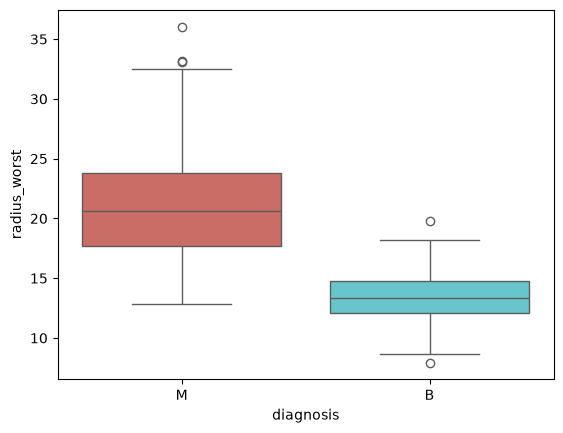

In [8]:
sb.boxplot(
    x="diagnosis",
    y="radius_worst",
    hue="diagnosis",
    data=dados,
    palette="hls",
    legend=False
)

Para fins academicos, para tratar dados nulos, no nosso projeto isso não foi necessário pois não existe colunas com dados nulos

In [9]:
# função inplace nao recomendada para alterar dados direto na 
# na base de dados original
# dados["Unnamed"].fillna(value=0, inplace=True)


Abaixo uma forma gráfica de analisar os valores de uma certa variavel utilizando boxplot

<Axes: xlabel='perimeter_worst'>

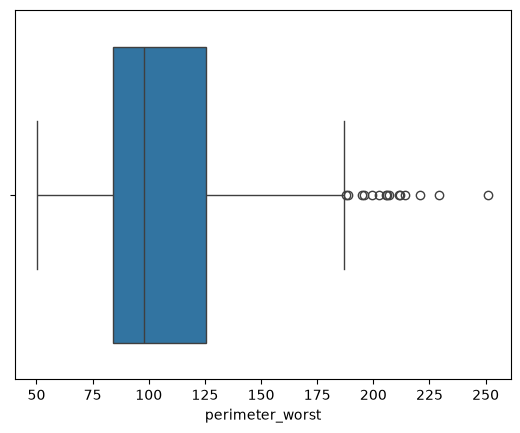

In [10]:
sb.boxplot(x=dados["perimeter_worst"])

histplot - Exibe um grafico de barras com os dados da coluna em questão
entendemos que este grafico é melhor para visualizar os dados de uma variavel de forma mais precisa

<Axes: xlabel='perimeter_worst', ylabel='Count'>

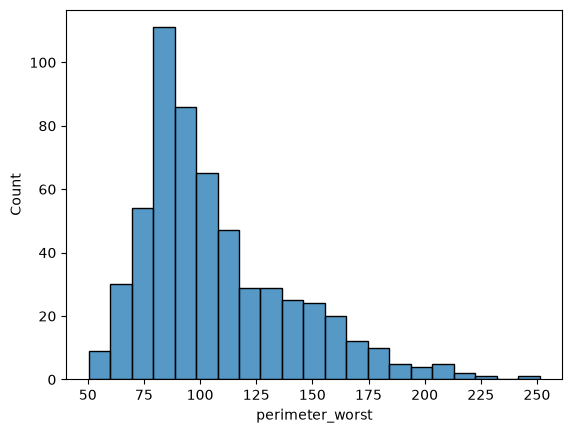

In [11]:
sb.histplot(data=dados,x="perimeter_worst")

Grafico de swarmplot para visualizar o agrupamento dos dados e a correlação com a nossa variavel target
em seguida executamos o grafico para as nossas 4 principais variaveis
"concave points_mean","concave points_worst","perimeter_worst","radius_worst"
o resultado nos mostra um agrupamento visual entre M e B na nossa variavel target

[Text(25.25, 0.5, 'Radios')]

c:\Users\domin\pos-tech\fase1\techchallenge\env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


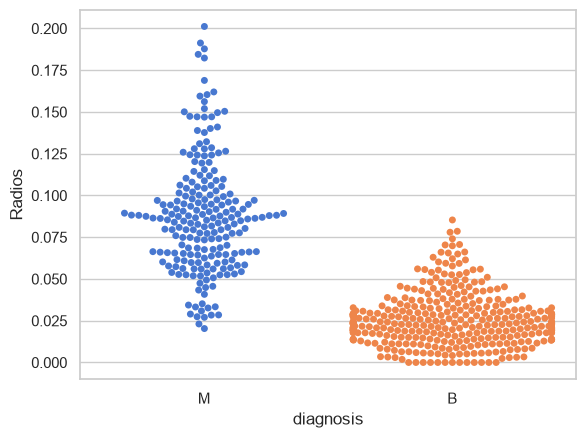

In [12]:
sb.set_theme(style="whitegrid", palette="muted")
ax = sb.swarmplot(data=dados, x="diagnosis", y="concave points_mean", hue="diagnosis")
ax.set(ylabel="Radios")




[Text(33.25, 0.5, 'Radios')]

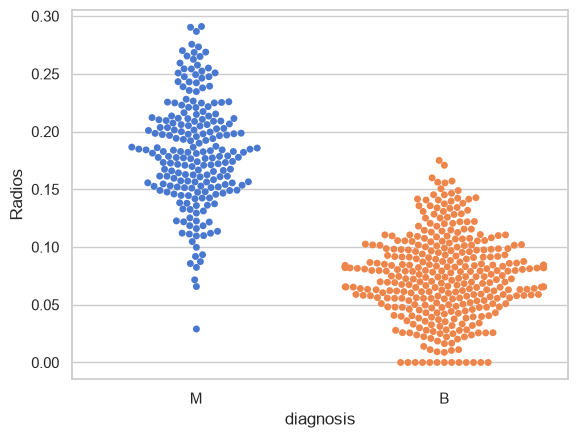

In [13]:
sb.set_theme(style="whitegrid", palette="muted")
ax = sb.swarmplot(data=dados, x="diagnosis", y="concave points_worst", hue="diagnosis")
ax.set(ylabel="Radios")

[Text(37.25, 0.5, 'Radios')]

c:\Users\domin\pos-tech\fase1\techchallenge\env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


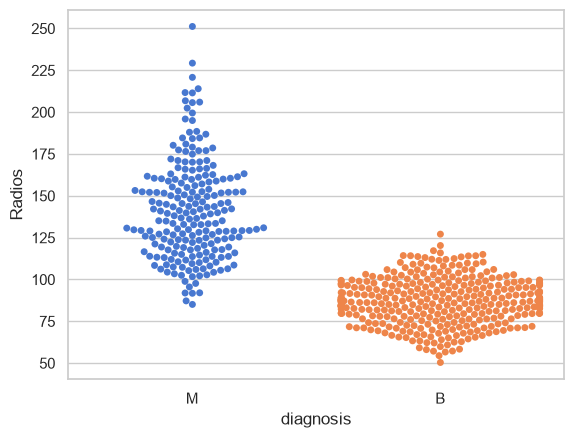

In [14]:
sb.set_theme(style="whitegrid", palette="muted")
ax = sb.swarmplot(data=dados, x="diagnosis", y="perimeter_worst", hue="diagnosis")
ax.set(ylabel="Radios")

[Text(45.25, 0.5, 'Radios')]

c:\Users\domin\pos-tech\fase1\techchallenge\env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


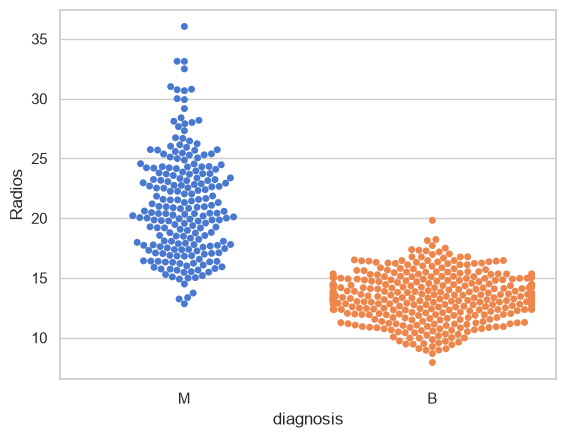

In [15]:
sb.set_theme(style="whitegrid", palette="muted")
ax = sb.swarmplot(data=dados, x="diagnosis", y="radius_worst", hue="diagnosis")
ax.set(ylabel="Radios")

O grafico de violin nos mostra mais detalhes e os valores dos dados ao mover o cursor do mouse sobre a area plotada  

In [16]:
import plotly_express as px

px.violin(dados,x="diagnosis",y="concave points_mean", color ="diagnosis",box=True, points="all")


In [17]:
px.violin(dados,x="diagnosis",y="concave points_worst", color ="diagnosis",box=True, points="all")

In [18]:
px.violin(dados,x="diagnosis",y="perimeter_worst", color ="diagnosis",box=True, points="all")

In [19]:
px.violin(dados,x="diagnosis",y="radius_worst", color ="diagnosis",box=True, points="all")

Neste ponto vamos tratar nossa variavel target diagnosis do tipo strig, transformar-la em numerico para ser entendida pelo modelo, para isso utilizamos o label encoder
M = 1 
B = 0


In [20]:
from sklearn.preprocessing import LabelEncoder
dados.head()
colunas = ["diagnosis"]

label_enconder = LabelEncoder()

for col in colunas:
    dados[col] = label_enconder.fit_transform(dados[col])
dados.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Importar biblioteca matplotlib.pyplot
analise do mapa de calor para entender a correlação entre as variaveis com diagnosis
segundo analise do grafico as variaveis concave points_mean","concave points_worst","perimeter_worst","radius_worst são as 4 com maior relação com a variavel target diagnosis, com 0,8



In [21]:
import  matplotlib.pyplot as plt



<Axes: >

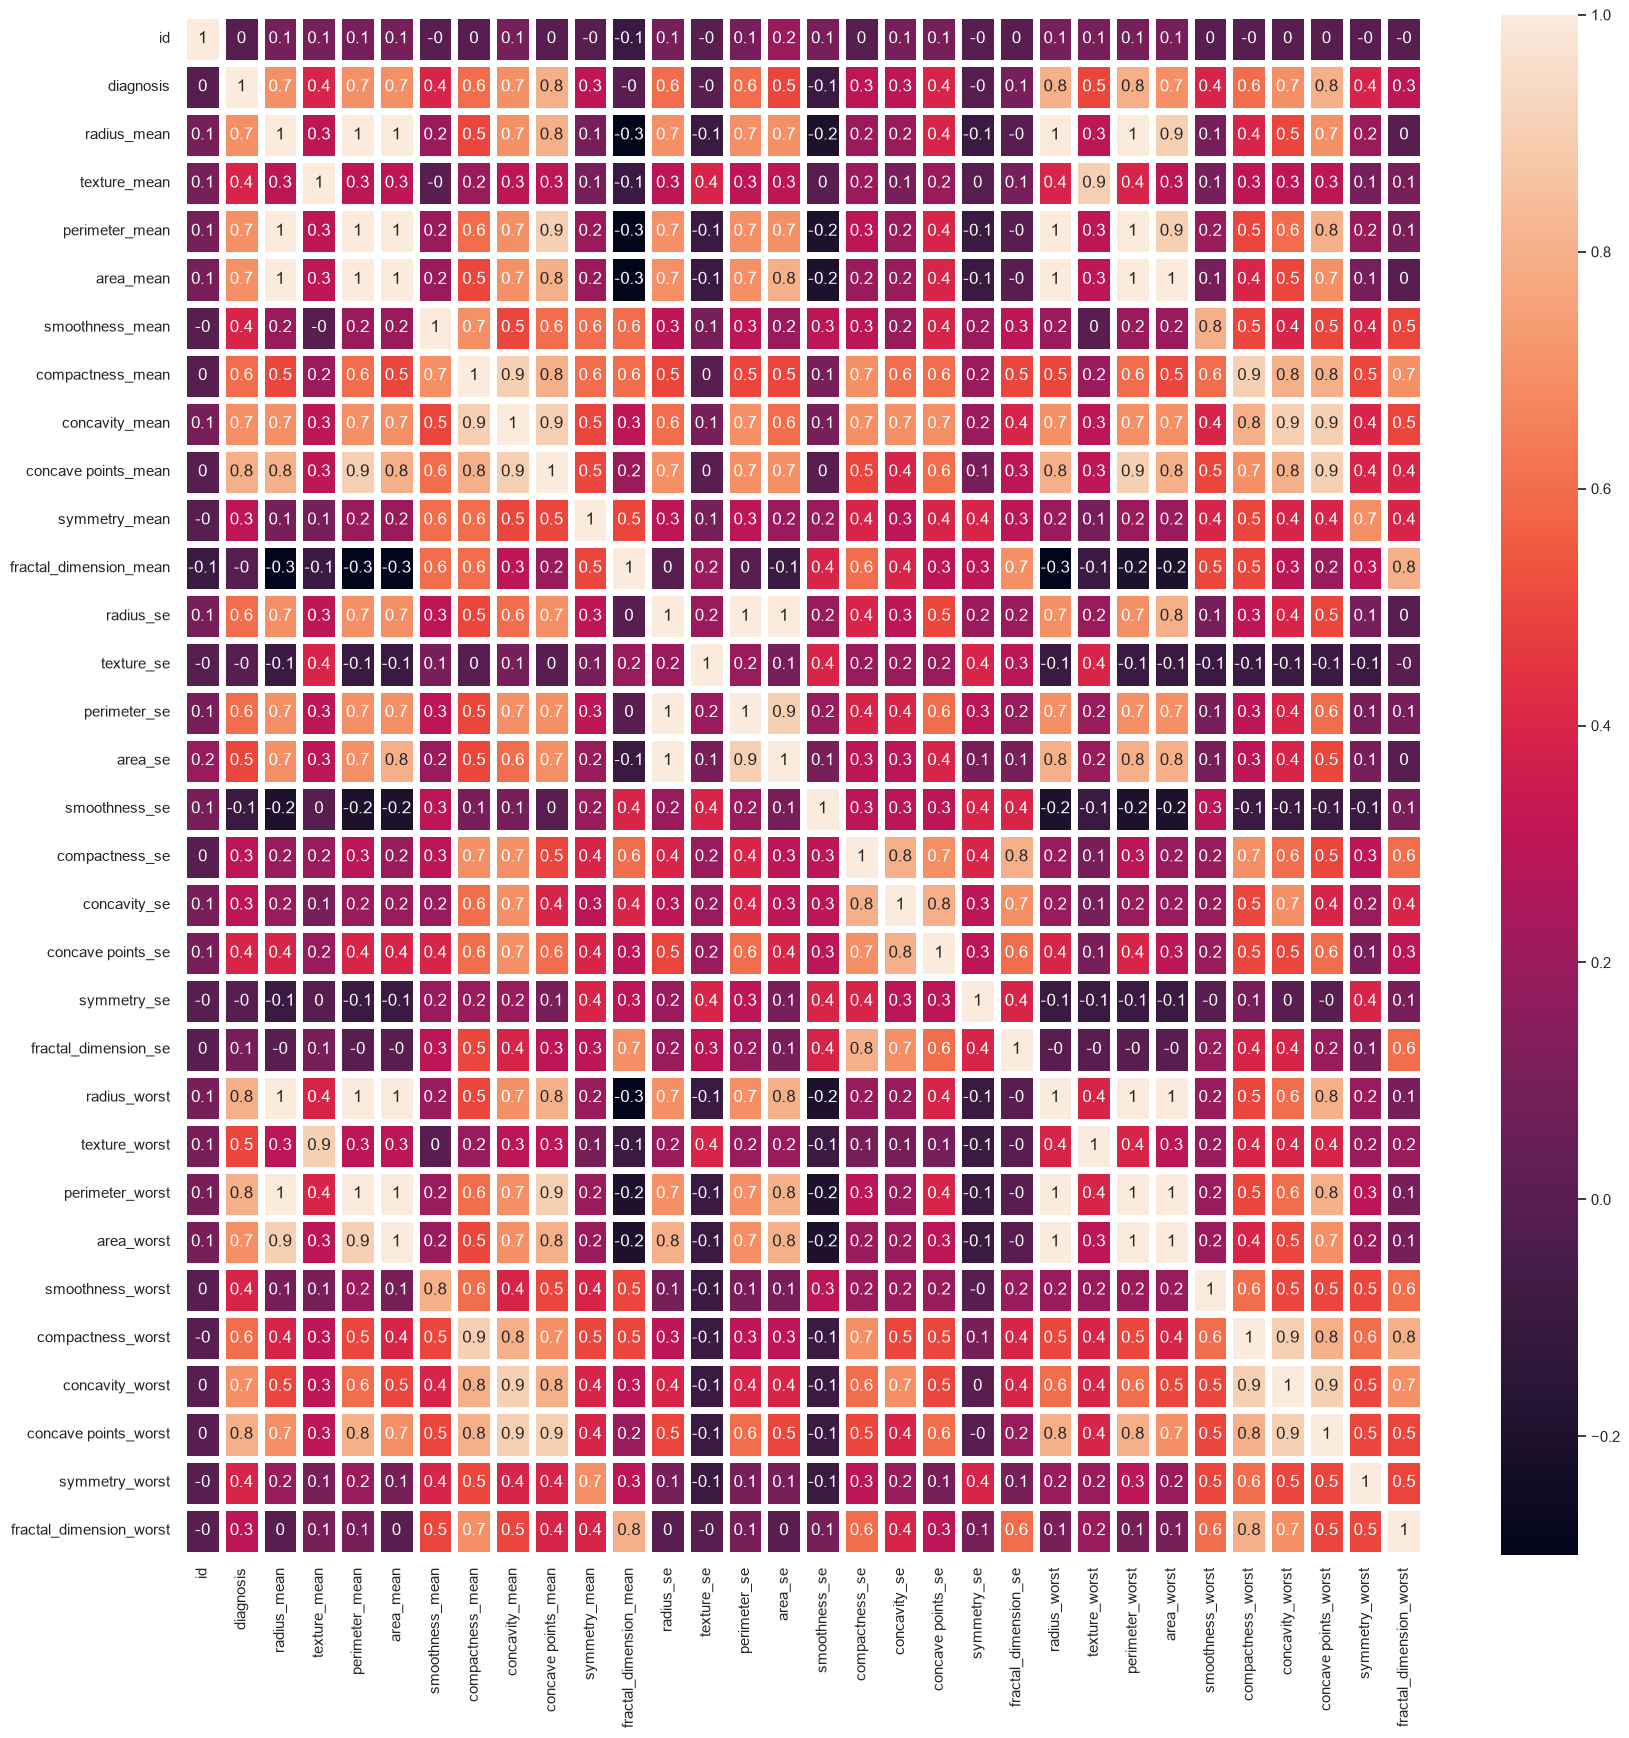

In [22]:
correlation_matriz = dados.corr().round(1)

fig, ax = plt.subplots(figsize=(20,20))
sb.heatmap(data=correlation_matriz,annot=True,linewidths=5,ax=ax )

criar variaveis para os modelos 
na primeira execução haviamos utilziado drop da coluna nula (Unnamed), porém após analise identificamos que a virgula extra estava causando o problema, então deixamos essa parte comentada no codigo e selecionamos as 4 principais variaveis com correlação de 80% na nossa variável target

In [23]:
x = dados[["concave points_mean","concave points_worst","perimeter_worst","radius_worst"]]
#x = dados.drop(columns=["Unnamed"])
y = dados["diagnosis"]

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


Serparar os dados entre treino e teste, sendo 70% para treinamento e 30% para testes

In [24]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)







In [25]:
print(x_test)

     concave points_mean  concave points_worst  perimeter_worst  radius_worst
448             0.029250               0.09594           108.10        16.300
346             0.008488               0.05093            86.54        13.640
568             0.000000               0.00000            59.16         9.456
411             0.024800               0.07431            79.93        12.410
519             0.029950               0.08045            93.63        14.450
..                   ...                   ...              ...           ...
74              0.022720               0.08660            89.71        14.110
39              0.054390               0.22580           107.30        15.530
99              0.058390               0.15650           109.50        16.330
115             0.020080               0.07247            87.54        13.670
219             0.066370               0.16250           180.20        27.900

[171 rows x 4 columns]


Padronização dos dados na mesma escala

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [27]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)


importar biblioteca numpy 

In [28]:
import numpy as np


Verificação do erro em K, analisando 10 "vizinhos"

Text(0, 0.5, 'Erro Medio')

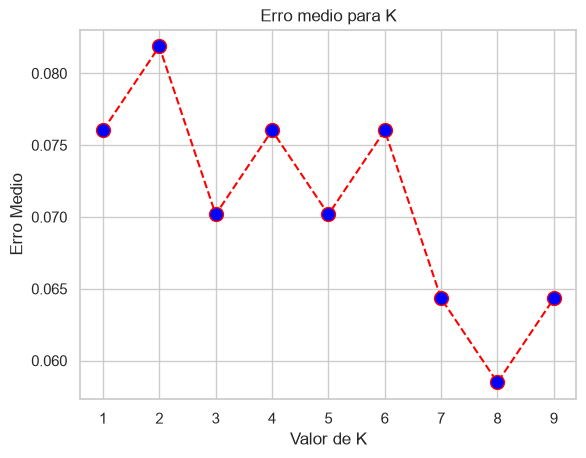

In [29]:
error = []

for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_escalonado, y_train)
    pred_i = knn.predict(x_test_escalonado)
    error.append(np.mean(pred_i != y_test))


plt.Figure(figsize=(12,6))
plt.plot(range(1,10),error,color="red",linestyle="dashed", marker="o",markerfacecolor="blue", markersize=10 )
plt.title("Erro medio para K")
plt.xlabel("Valor de K")
plt.ylabel("Erro Medio")



criar modelo classificados

In [30]:
modelo_classificador_knn = KNeighborsClassifier(n_neighbors=5)
modelo_classificador_knn.fit(x_train_escalonado,y_train)

y_predict_knn = modelo_classificador_knn.predict(x_test_escalonado)
y_predict_knn

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1])

avaliar a performance/acuracia do modelo
o modelo se mostrou como uma acuracia muito boa com 0.9298245614035088

In [31]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_predict_knn))

0.9298245614035088


Comparar o modelo com outro modelo SVM, com modelo SVM a acuracia ficou melhor chegando a 0.9649122807017544

In [32]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [33]:
modelo_classificador_svm = Pipeline(
    [
        ("linear_svc",LinearSVC(C=1))
    ]
)

modelo_classificador_svm.fit(x_train_escalonado,y_train)

y_predict_svm = modelo_classificador_svm.predict(x_test_escalonado)

print(accuracy_score(y_test, y_predict_svm))



0.9649122807017544


com o modelo random forest obtivemos uma acuracia de 93%

In [34]:
from sklearn.ensemble import RandomForestClassifier # RandomForest

In [35]:
  # RandomForest
modelo_classificador_rf = RandomForestClassifier(random_state=7) 
modelo_classificador_rf.fit(x_train_escalonado, y_train) 
y_predict_rf = modelo_classificador_rf.predict(x_test_escalonado)
print(accuracy_score(y_test, y_predict_rf))

0.935672514619883


Entendemos que para um algoritimo que preve possibilidade de uma pessoa possuir um tumor é muito mais imoportante prever como falso posivivo do que falso negativo, porque embora a informação de tumor vai causar um impacto emocional na pessoa ela terá oportunidade de fazer mais exames e comprovar que está saudadel, o inverso pode resultar na falta de tratamento e investigação e a pessoa pode não ter tempo habil para se tratar quando a doença evoluir
abaixo nossas analises das metricas

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Analisando os resultados, mapa de calor

para o modelo KNN 
falso verdadeiro: 10
falso negativo: 2

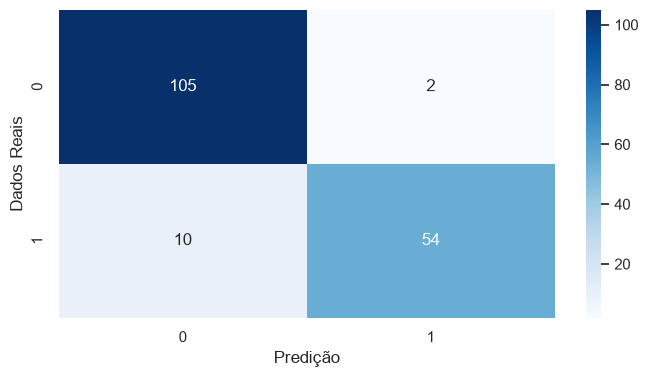

In [37]:
matriz_confusao = confusion_matrix(y_test, y_predict_knn)
plt.figure(figsize = (8, 4))
sb.heatmap(matriz_confusao, annot = True, fmt="d",cmap = "Blues")
plt.xlabel("Predição");
plt.ylabel("Dados Reais");

para o modelo SVM
falso verdadeiro: 4
falso negativo: 2

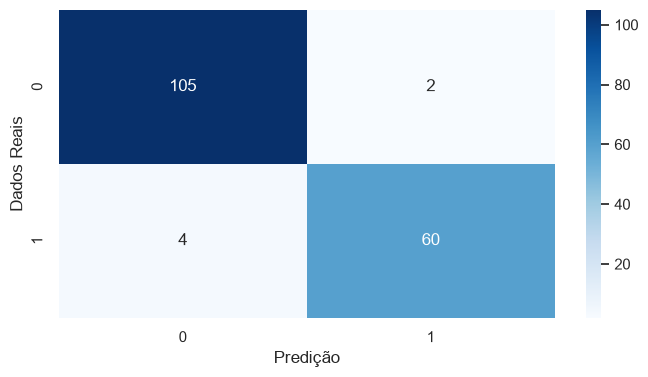

In [38]:
matriz_confusao = confusion_matrix(y_test, y_predict_svm)
plt.figure(figsize = (8, 4))
sb.heatmap(matriz_confusao, annot = True, fmt="d",cmap = "Blues")
plt.xlabel("Predição");
plt.ylabel("Dados Reais");

Para o modelo Random Forest
falso verdadeiro: 7
falso negativo: 4

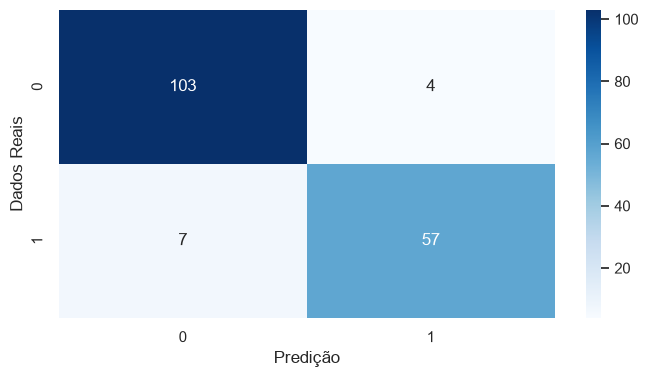

In [39]:
matriz_confusao = confusion_matrix(y_test, y_predict_rf)
plt.figure(figsize = (8, 4))
sb.heatmap(matriz_confusao, annot = True, fmt="d",cmap = "Blues")
plt.xlabel("Predição");
plt.ylabel("Dados Reais");

Conclusão
Para o cenario de predição de laudos de cancer o melhor modelo foi o SVM pois errou somente 2 casos de falso negativo
falso verdadeiro: 4
falso negativo: 2

In [40]:
from sklearn.metrics import classification_report #métricas de avaliação

Comparando com as metricas, se comprova que SVM teve melhor performance pricipalmente comparando com a metrica precision

In [41]:
print(classification_report(y_test, y_predict_knn))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       107
           1       0.96      0.84      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171



In [42]:
print(classification_report(y_test, y_predict_svm))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       107
           1       0.97      0.94      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [43]:
print(classification_report(y_test, y_predict_rf))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       107
           1       0.93      0.89      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



Utilizando a curva ROC e AUC para validar a sensibildade do modelo

In [44]:
from sklearn import metrics
from sklearn.metrics import roc_curve, auc

Testando o ROC para o modelo KNN

In [45]:
y_prob_knn = modelo_classificador_knn.predict_proba(x_test_escalonado)[:,1] 
false_positive_rate_knn, true_positive_rate_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(false_positive_rate_knn, true_positive_rate_knn)
roc_auc_knn

0.992698598130841

Text(0.5, 0, 'False Positive Rate')

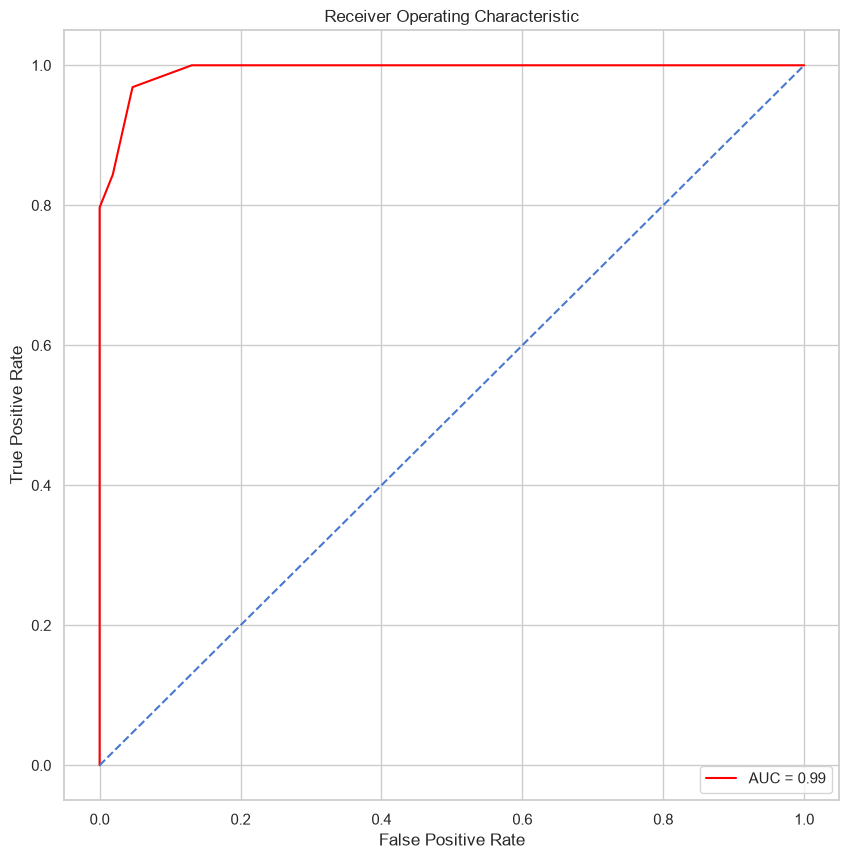

In [46]:
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate_knn,true_positive_rate_knn, color='red',label = 'AUC = %0.2f' % roc_auc_knn)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

Testando o ROC para o modelo SVM
Conclusão: após rodar o ROC e AUC para os tres modelos, o modelo SVM possui a melhor sensibilidade

In [47]:
y_prob_svm = modelo_classificador_svm.decision_function(x_test_escalonado)
false_positive_rate_svm, true_positive_rate_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(false_positive_rate_svm, true_positive_rate_svm)
roc_auc_svm

0.9967873831775701

Text(0.5, 0, 'False Positive Rate')

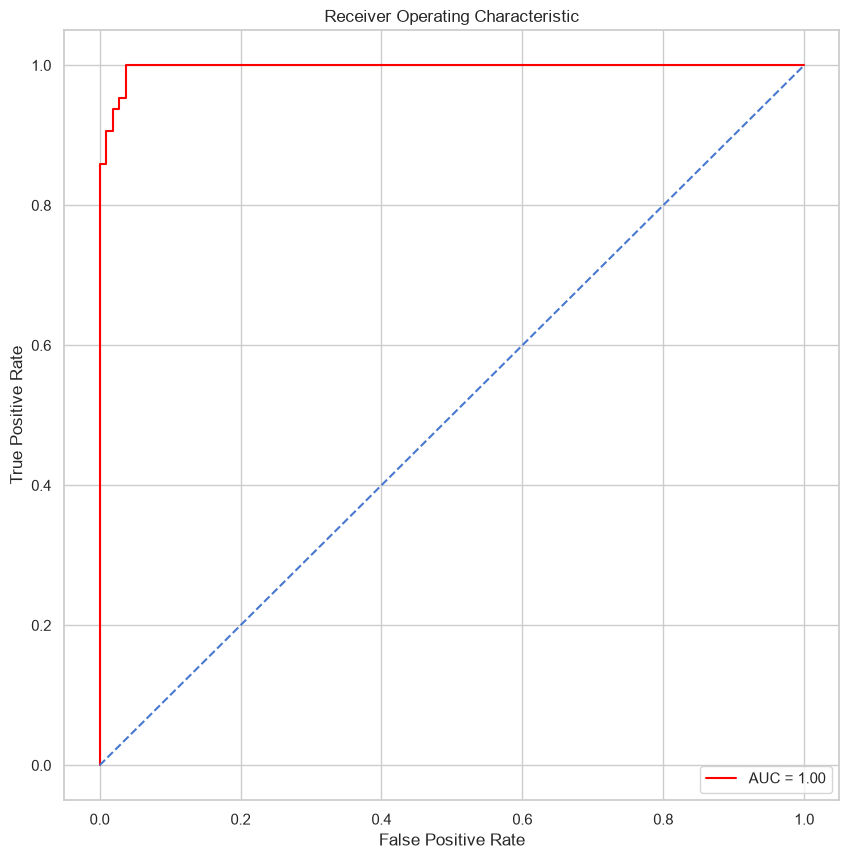

In [48]:
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate_svm,true_positive_rate_svm, color='red',label = 'AUC = %0.2f' % roc_auc_svm)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

Testando o ROC para o modelo RF

In [49]:
y_prob_rf = modelo_classificador_rf.predict_proba(x_test_escalonado)[:,1] 
false_positive_rate_rf, true_positive_rate_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(false_positive_rate_rf, true_positive_rate_rf)
roc_auc_rf

0.9886828271028036

Text(0.5, 0, 'False Positive Rate')

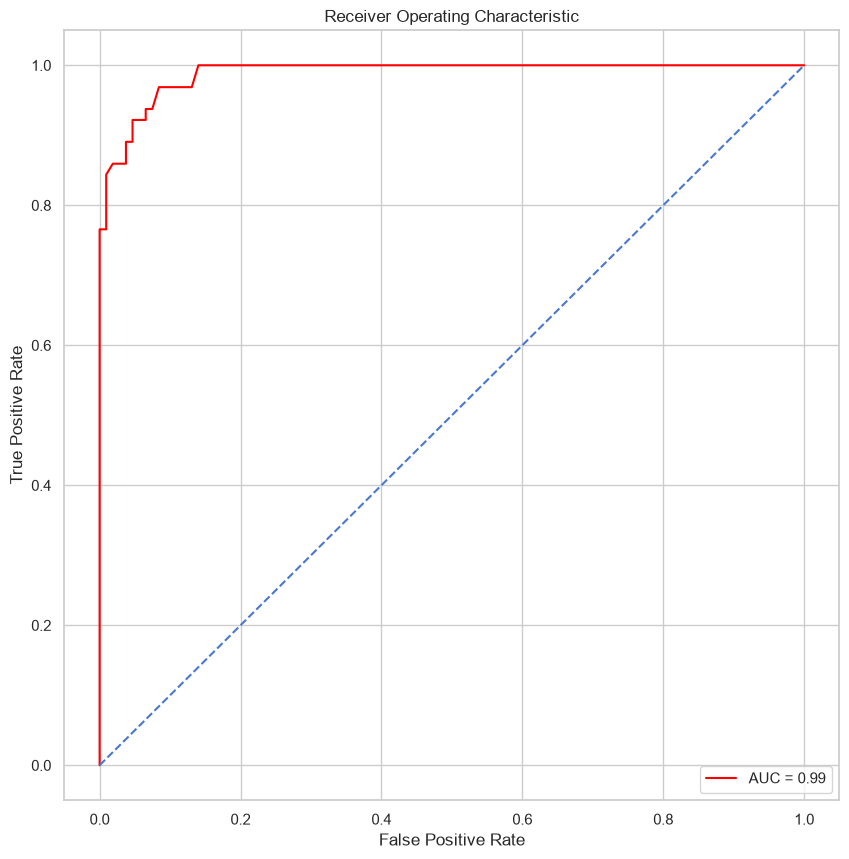

In [50]:
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate_rf,true_positive_rate_rf, color='red',label = 'AUC = %0.2f' % roc_auc_rf)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

Conclusão final:
De acordo com as métricas disponiveis até o momento, para o nosso projeto o modelo que melhor prevê se uma pessoa tem ou não um tumor é o modelo SVM, possui uma taxa de acuracia de 96% o que é considerado excelente.
Nosso projeto auxilia o profissional de saude a identificar a doença, porém o profissional é quem realmente esta de fato qualificado a fornecer o laudo final ao paciente.

Salvar o modelo treinado

In [51]:
import pickle
filename = 'modelo_pipeline.pkl'

pickle.dump(modelo_classificador_svm, open(filename, 'wb'))

print(f"Pipeline exported to {filename}")

Pipeline exported to modelo_pipeline.pkl


Para carregar o modelo e fazer predições


In [54]:
import pickle
modelo_salvo = pickle.load(open("modelo_pipeline.pkl","rb"))
modelo_salvo.predict(x_test_escalonado)


array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1])